# Arboreal Jump Number: Feasibility vs Heuristic Analysis
This notebook analyzes the performance and solution quality differences between the exact `FEASIBILITY` solver and the `SMART_HEURISTIC`.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
# Load data from the parent directory
csv_path = '../result_feasibility_vs_heuristic.csv'
df = pd.read_csv(csv_path)
df.head()

,instance,algorithm,num_jumps,num_explored_nodes,primal_bound,dual_bound,cuts_added_by_solver,status,mean_in_degree,nodes_indegree_gt_one,closed_edge_density,num_edges,num_closed_edges,group_id,algorithm_right,max_in_degree,num_nodes,instance_type,runtime
0,n10o0.7-8.rcp,FEASIBILITY,3.0,0,4.0,4.0,0.0,2.0,1.384615,5,0.820513,18,64,n10,FEASIBILITY,3,13,generated,0.128368
1,n10os0.9-10.rcp,FEASIBILITY,2.0,0,3.0,3.0,0.0,2.0,1.153846,3,0.935897,15,73,n10,FEASIBILITY,2,13,generated,0.050630
2,n50os0.95-2.rcp,FEASIBILITY,17.0,1,18.0,18.0,0.0,2.0,1.735849,32,0.955007,92,1316,n50,FEASIBILITY,3,53,generated,6976.115142
3,n10os0.9-6.rcp,SMART_HEURISTIC,2.0,0,0.0,0.0,0.0,NaN,1.153846,3,0.935897,15,73,n10,FEASIBILITY,2,13,generated,0.002206
4,n70os0.95-2.rcp,SMART_HEURISTIC,27.0,0,0.0,0.0,0.0,NaN,1.876712,44,0.953957,137,2507,n70,FEASIBILITY,3,73,generated,0.251627


## 1. Data Preprocessing
We filter the dataset for the algorithms we want to compare and pivot the table to place the results of `FEASIBILITY` and `SMART_HEURISTIC` side-by-side for each problem instance.

In [21]:
df_filtered = df[df['algorithm'].isin(['FEASIBILITY', 'SMART_HEURISTIC'])].copy()
time_col = 'runtime'

# Pivot data
pivot_df = df_filtered.pivot_table(
    index='instance', 
    columns='algorithm', 
    values=['num_jumps', time_col], 
    aggfunc='first'
)

# Flatten the multi-level columns
pivot_df.columns = [f'{val}_{col}' for val, col in pivot_df.columns]
# pivot_df = pivot_df.dropna()
pivot_df.head()

,num_jumps_FEASIBILITY,num_jumps_SMART_HEURISTIC,runtime_FEASIBILITY,runtime_SMART_HEURISTIC
instance,,,,
br17.10.sop.ajn.txt,1.0,1.0,0.021302,0.004320
br17.12.sop.ajn.txt,2.0,2.0,0.148419,0.002401
esc07.sop.ajn.txt,2.0,2.0,0.023121,0.001385
esc11.sop.ajn.txt,0.0,0.0,0.003753,0.001283
esc12.sop.ajn.txt,5.0,5.0,4.044927,0.003070


In [22]:
pivot_df.shape

(449, 4)

## 2. Comparative Analysis: Solution Quality
Comparing the number of jumps found by the heuristic versus the exact bounds from the exact solver.

In [23]:
num_instances = len(pivot_df)
exact_matches = (pivot_df['num_jumps_FEASIBILITY'] == pivot_df['num_jumps_SMART_HEURISTIC']).sum()
match_percentage = (exact_matches / num_instances) * 100

pivot_df['jump_diff'] = pivot_df['num_jumps_SMART_HEURISTIC'] - pivot_df['num_jumps_FEASIBILITY']

print(f'Total Instances: {num_instances}')
print(f'Exact Matches: {exact_matches} ({match_percentage:.2f}%)')
print(f'Average Jump Difference (Heuristic - Exact): {pivot_df["jump_diff"].mean():.2f}')

failed_heuristic = pivot_df[pivot_df['jump_diff'] > 0]
if not failed_heuristic.empty:
    print(f'Average gap when failing: {failed_heuristic["jump_diff"].mean():.2f}')

Total Instances: 449
Exact Matches: 126 (28.06%)
Average Jump Difference (Heuristic - Exact): 0.47
Average gap when failing: 1.44


## 3. Comparative Analysis: Execution Time
Analyzing the `runtime` column to evaluate performance.

In [24]:
time_stats = pd.DataFrame({
    'FEASIBILITY (s)': pivot_df[f'{time_col}_FEASIBILITY'].describe(),
    'SMART_HEURISTIC (s)': pivot_df[f'{time_col}_SMART_HEURISTIC'].describe()
})
display(time_stats)


,FEASIBILITY (s),SMART_HEURISTIC (s)
count,187.000000,449.000000
mean,1931.473611,3.804141
std,5052.221229,36.844219
min,0.003753,0.001283
25%,0.303506,0.011397
50%,9.821757,0.075655
75%,341.177357,0.220432
max,27861.728698,495.299549


## 4. Instance Characteristics Correlation
Analyzing how the problem properties affect the `FEASIBILITY` execution time.

In [28]:
# Merge instance characteristics back in
features = df_filtered[['instance', 'num_nodes', 'num_edges', 'mean_in_degree', 'closed_edge_density', 'instance_type']].drop_duplicates(subset=['instance'])
merged_df = pivot_df.merge(features, on='instance')

corr_cols = [f'{time_col}_FEASIBILITY', 'num_nodes', 'num_edges', 'mean_in_degree', 'closed_edge_density']
corr_matrix = merged_df[corr_cols].corr()

display(corr_matrix[[f'{time_col}_FEASIBILITY']].sort_values(by=f'{time_col}_FEASIBILITY', ascending=False))

,runtime_FEASIBILITY
runtime_FEASIBILITY,1.000000
num_edges,0.709474
mean_in_degree,0.496077
num_nodes,0.436017
closed_edge_density,0.116140


## 5. Aggregation by Instance Type
We can see how the performance breaks down by the `instance_type` (e.g. `generated` vs `sop`).

In [29]:
agg_jumps = merged_df.groupby('instance_type')[['num_jumps_FEASIBILITY', 'num_jumps_SMART_HEURISTIC']].mean()
display(agg_jumps)

agg_time = merged_df.groupby('instance_type')[[f'{time_col}_FEASIBILITY', f'{time_col}_SMART_HEURISTIC']].mean()
display(agg_time)

,num_jumps_FEASIBILITY,num_jumps_SMART_HEURISTIC
instance_type,,
generated,7.840237,18.906863
sop,2.055556,43.292683


,runtime_FEASIBILITY,runtime_SMART_HEURISTIC
instance_type,,
generated,2135.004959,0.130509
sop,20.540392,40.361256


## 6. Visualizations
Visualizing execution time distribution and solution quality gaps.

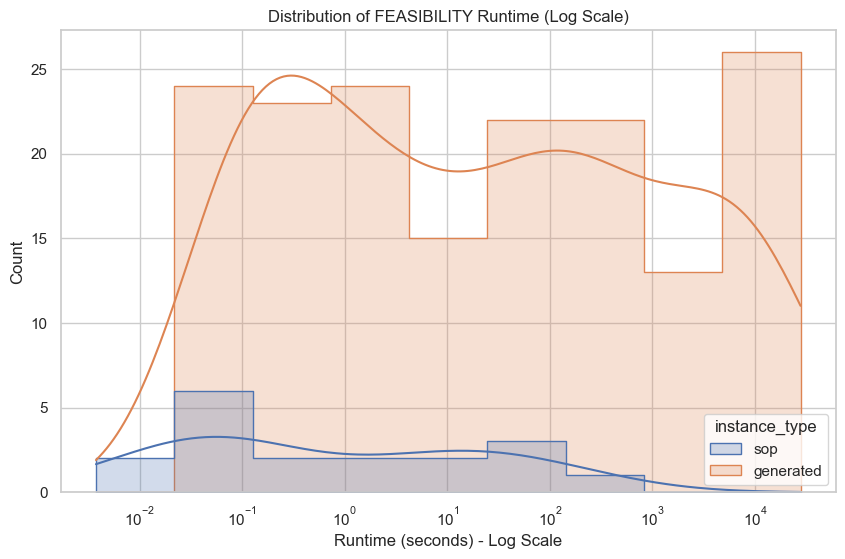

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=merged_df[merged_df[f'{time_col}_FEASIBILITY'] > 0], 
    x=f'{time_col}_FEASIBILITY', 
    hue='instance_type', 
    log_scale=True, 
    kde=True,
    element='step'
)
plt.title('Distribution of FEASIBILITY Runtime (Log Scale)')
plt.xlabel('Runtime (seconds) - Log Scale')
plt.ylabel('Count')
plt.show()

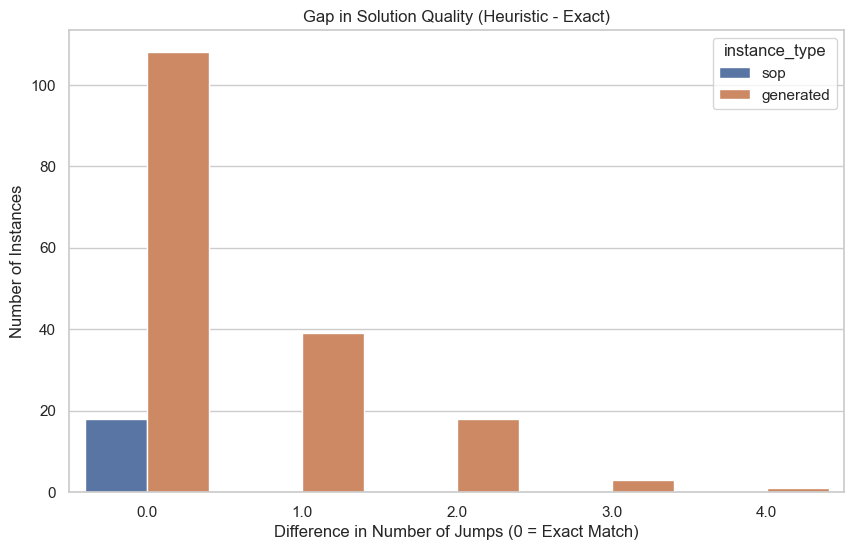

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_df, x='jump_diff', hue='instance_type')
plt.title('Gap in Solution Quality (Heuristic - Exact)')
plt.xlabel('Difference in Number of Jumps (0 = Exact Match)')
plt.ylabel('Number of Instances')
plt.show()